# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [ ]:
! pip install palmerpenguins

In [ ]:
import palmerpenguins
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from plotnine import *

In [108]:
penguins_df = palmerpenguins.load_penguins()
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)->note, we HAVE to standardize here!
* A decision tree model->don't have to standardize

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [109]:
#drop NAs
penguins_df = penguins_df.dropna()

In [110]:
#full data for cross validation
X = penguins_df.drop(["bill_depth_mm"], axis = 1)
y = penguins_df["bill_depth_mm"]

In [111]:
X.head()

,species,island,bill_length_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,190.0,3650.0,male,2007


In [112]:
y.head()

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6


In [113]:
X.dtypes

,0
species,object
island,object
bill_length_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [115]:
#define column transformer that dummifies and standardizes variables
ct_dummify_stdz = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

In [116]:
#define column transformer that dummifies variables
ct_dummify = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

In [117]:
#define column transformer that passes variable(s) of interest through and dummifies variables
ct_pass_var = ColumnTransformer(
  [
      ("passVar", "passthrough", ["remainder__bill_length_mm"])
  ],
  remainder = "drop" #drop the remaining variables in the data set
).set_output(transform = "pandas")

In [118]:
ct_dummify_stdz.fit_transform(X)

,dummify__species_Adelie,dummify__species_Chinstrap,dummify__species_Gentoo,dummify__island_Biscoe,dummify__island_Dream,dummify__island_Torgersen,dummify__sex_female,dummify__sex_male,standardize__bill_length_mm,standardize__flipper_length_mm,standardize__body_mass_g,standardize__year
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.896042,-1.426752,-0.568475,-1.283742
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.822788,-1.069474,-0.506286,-1.283742
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.676280,-0.426373,-1.190361,-1.283742
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.335566,-0.569284,-0.941606,-1.283742
5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.859415,-0.783651,-0.692852,-1.283742
...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.162314,0.431094,-0.257532,1.180155
340,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.090248,0.073816,-1.003795,1.180155
341,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.026876,-0.569284,-0.537380,1.180155
342,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.246638,0.645461,-0.133155,1.180155


In [119]:
ct_dummify.fit_transform(X)

,dummify__species_Adelie,dummify__species_Chinstrap,dummify__species_Gentoo,dummify__island_Biscoe,dummify__island_Dream,dummify__island_Torgersen,dummify__sex_female,dummify__sex_male,remainder__bill_length_mm,remainder__flipper_length_mm,remainder__body_mass_g,remainder__year
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,39.1,181.0,3750.0,2007
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,39.5,186.0,3800.0,2007
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,40.3,195.0,3250.0,2007
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,36.7,193.0,3450.0,2007
5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,39.3,190.0,3650.0,2007
...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,55.8,207.0,4000.0,2009
340,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,43.5,202.0,3400.0,2009
341,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,49.6,193.0,3775.0,2009
342,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,50.8,210.0,4100.0,2009


In [120]:
#best linear regression model
lr_pipeline = Pipeline(
    [("preprocessing", ct_dummify),
    ("linear_regression", LinearRegression())]
)

#calculate test RMSE
lr_test_rmse = cross_val_score(lr_pipeline, X=X[['bill_length_mm', 'sex', 'flipper_length_mm', 'body_mass_g']], y=y, scoring="neg_mean_squared_error", cv=5)
lr_test_rmse = lr_test_rmse.mean()*-1
lr_test_rmse

np.float64(1.8261950023140063)

In [121]:
#kNN model with 3 nearest neighbors
kNN_pipeline1 = Pipeline(
          [("preprocessing", ct_dummify_stdz),
          ("kNN", KNeighborsRegressor(n_neighbors=3))]
)

#calculate test RMSE
kNN1_test_rmse = cross_val_score(kNN_pipeline1, X=X, y=y, scoring="neg_mean_squared_error", cv=5)
kNN1_test_rmse = kNN1_test_rmse.mean()*-1
kNN1_test_rmse

np.float64(1.1505668626564147)

In [122]:
#kNN model with 5 nearest neighbors
kNN_pipeline2 = Pipeline(
          [("preprocessing", ct_dummify_stdz),
          ("kNN", KNeighborsRegressor(n_neighbors=5))]
)

#calculate test RMSE
kNN2_test_rmse = cross_val_score(kNN_pipeline2, X=X, y=y, scoring="neg_mean_squared_error", cv=5)
kNN2_test_rmse = kNN2_test_rmse.mean()*-1
kNN2_test_rmse

np.float64(1.1918801266395296)

In [123]:
#decision tree
dt_pipeline = Pipeline(
  [("dummify", ct_dummify),
  ("decision_tree", DecisionTreeRegressor(max_depth=2))]
)

dt_pipeline

Pipeline(steps=[('dummify',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e3c3f6fba70>)])),
                ('decision_tree', DecisionTreeRegressor(max_depth=2))])

In [124]:
dt_pipeline.fit(X=X, y=y)

Pipeline(steps=[('dummify',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e3c3f6fba70>)])),
                ('decision_tree', DecisionTreeRegressor(max_depth=2))])

[Text(0.5, 0.8333333333333334, 'dummify__species_Gentoo <= 0.5\nsquared_error = 3.866\nsamples = 333\nvalue = 17.165'),
 Text(0.25, 0.5, 'dummify__sex_male <= 0.5\nsquared_error = 1.412\nsamples = 214\nvalue = 18.371'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.787\nsamples = 107\nvalue = 17.611'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.884\nsamples = 107\nvalue = 19.13'),
 Text(0.75, 0.5, 'dummify__sex_female <= 0.5\nsquared_error = 0.964\nsamples = 119\nvalue = 14.997'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.54\nsamples = 61\nvalue = 15.718'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.287\nsamples = 58\nvalue = 14.238')]

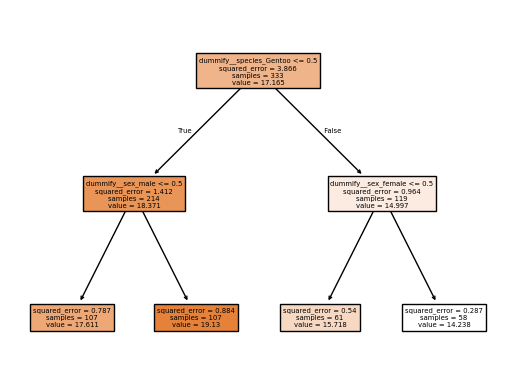

In [125]:
from sklearn.tree import plot_tree

# Access the Decision Tree estimator by its name in the pipeline
decision_tree_estimator = dt_pipeline.named_steps['decision_tree']

feat_names = dt_pipeline.named_steps["dummify"].get_feature_names_out(
    input_features=getattr(X, "columns", None)
)


# Plot the decision tree
plot_tree(decision_tree_estimator, feature_names=feat_names, filled = True)

In [126]:
#calculate test RMSE
dt_test_rmse = cross_val_score(dt_pipeline, X=X, y=y, scoring="neg_mean_squared_error", cv=5)
dt_test_rmse = dt_test_rmse.mean()*-1
dt_test_rmse

np.float64(0.759931366577835)

In [127]:
error_df = {'Model': ["linear","kNN1", "kNN2", "dt"], 'Test RMSE': [lr_test_rmse, kNN1_test_rmse, kNN2_test_rmse, dt_test_rmse]}

error_df = pd.DataFrame(error_df)
error_df

,Model,Test RMSE
0,linear,1.826195
1,kNN1,1.150567
2,kNN2,1.191880
3,dt,0.759931


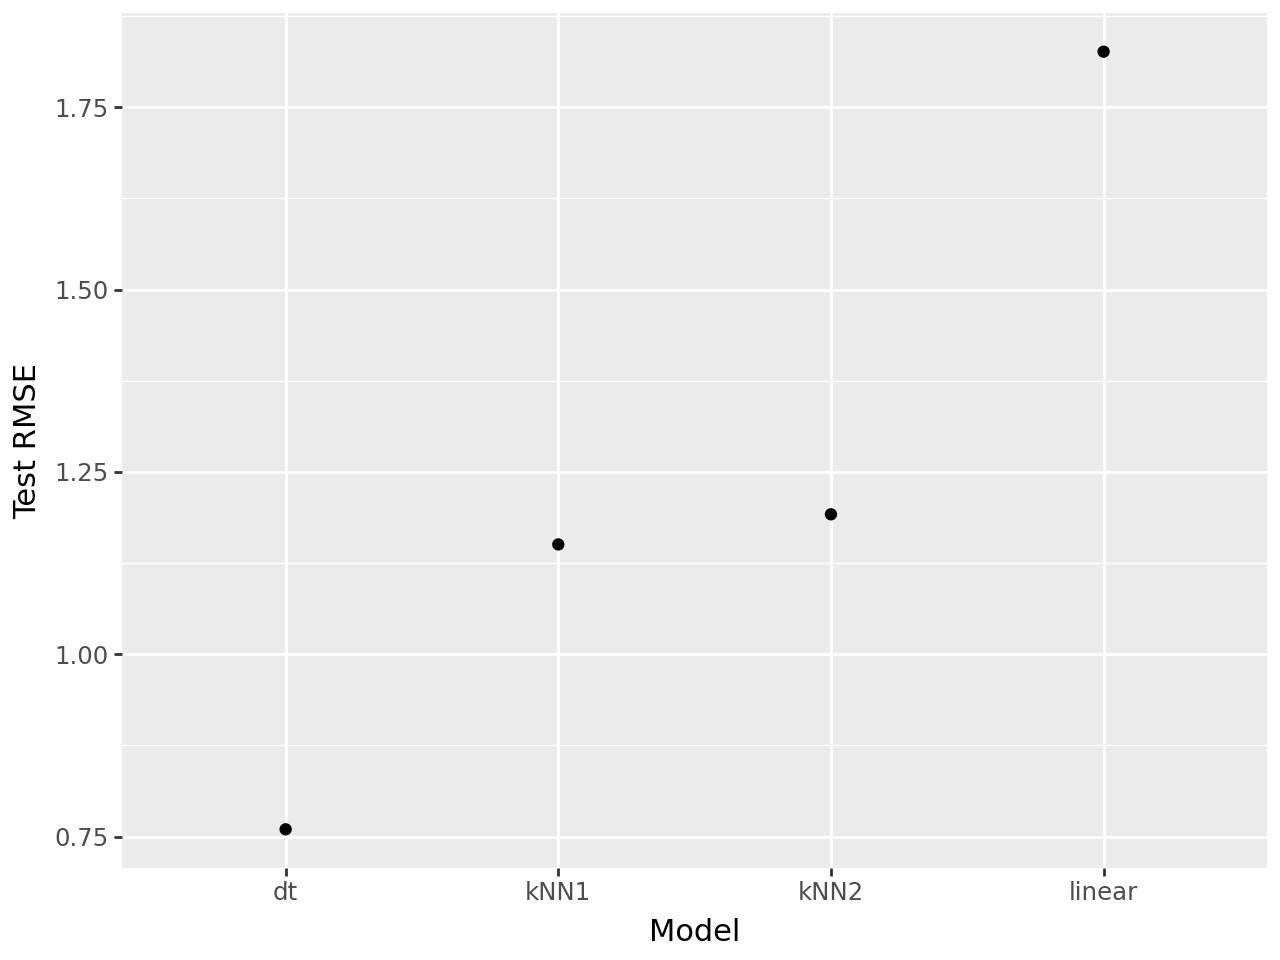

In [128]:
#plot train vs. test error
(ggplot(error_df,
        aes(x = "Model",
            y = "Test RMSE"))
+ geom_point()
)

*Note: Professor Ross asked us not to partition the data into training and test sets and only use cross validation. He said that displaying only the test RMSE is okay.


It appears that the model that performs the best in predicting bill depth is the decision tree model with species and sex as nodes/predictors due to having the smallest test RMSE value.